# Chapter 7 — What makes a kernel learnable

*Companion notebook to **The Learned Kernel**, Ch. 7. Run top to bottom.*

Once a kernel carries parameters, its **geometry** can be overfit — and ordinary
in-sample criteria credit the most flexible kernel dishonestly. A near-interpolating
kernel (the supervised leaf kernel of Ch. 4) looks best on the very data it was fit on.
The cure is to score the kernel on a held-out **query** fold it never touched. This
notebook shows the over-credit on the running data, shows SURE tracking the true risk
for a *fixed* smoother, and reads the two-term capacity map.

**The frame** — *what is learned · how scored · what you read off.* We learn the kernel's
own parameters (the family and the fusion weights/ridge). We score them on a held-out
query fold (leakage-free). You read off the selected weights and the per-channel
support-vs-query gap — a large gap is a channel asking for unearned credit.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import load_california, set_style
from lkbook.chapters import ch07

set_style()
cal = load_california()

## 7.1  The over-credit problem

Score three candidate kernels — a **chosen RBF**, the **learned ARD** kernel (Ch. 3), and
the **supervised leaf/tree** kernel (Ch. 4) — each fit on the support fold. Compare
in-sample support R² to held-out query R². The leaf kernel nearly interpolates its
support (support R² ≈ 1) but its query R² is much lower — that gap is the over-credit.

In [3]:
rows = ch07.per_channel_credit(cal)
tbl = pd.DataFrame(rows).set_index("name")[["support_r2", "query_r2", "gap", "test_rmse"]]
tbl.columns = ["support R² (in-sample)", "query R² (held out)", "gap", "test RMSE"]
tbl.round(4)

,support R² (in-sample),query R² (held out),gap,test RMSE
name,,,,
RBF (chosen),0.8551,0.6909,0.1643,0.6443
"ARD (learned, Ch. 3)",0.8616,0.7393,0.1223,0.5934
leaf / tree (Ch. 4),0.9997,0.7191,0.2806,0.5689


The leaf kernel's support R² towers over its query R²: a deep forest memorizes the
support labels almost exactly and carries less of it to held-out cases. An in-sample
selector would crown it; a held-out selector sees through it.

## 7.2  In-sample vs query-fold selection

Fuse the three channels two ways. **In-sample** selection grids the simplex × ridge by
SURE on the support — a smoother that saw the labels through the supervised tree, so it
undercounts the tree's degrees of freedom and over-credits it. **Query-fold** selection
grids the same simplex by held-out query R² — leakage-free.

In [4]:
sel = ch07.select_in_sample_vs_query(cal)
print(f"estimated noise sigma^2 from the GCV optimum = {sel['sigma2']:.4f}  "
      "(absurdly small — the near-interpolating tree explains the support residual away)\n")
sel_tbl = pd.DataFrame({
    "in-sample (SURE)": {**{k: round(v, 2) for k, v in sel["in_sample"]["weights"].items()},
                         "ridge λ": sel["in_sample"]["lam"],
                         "test RMSE": round(sel["in_sample"]["test_rmse"], 3)},
    "query fold": {**{k: round(v, 2) for k, v in sel["query"]["weights"].items()},
                   "ridge λ": sel["query"]["lam"],
                   "test RMSE": round(sel["query"]["test_rmse"], 3)},
})
sel_tbl

estimated noise sigma^2 from the GCV optimum = 0.0018  (absurdly small — the near-interpolating tree explains the support residual away)



,in-sample (SURE),query fold
RBF (chosen),0.000000,0.170
"ARD (learned, Ch. 3)",0.000000,0.670
leaf / tree (Ch. 4),1.000000,0.170
ridge λ,0.004642,0.100
test RMSE,0.571000,0.546


In [5]:
# the over-credit asserted: in-sample hands the tree all the weight; query collapses it
leaf = "leaf / tree (Ch. 4)"
print(f"leaf weight  in-sample={sel['in_sample']['weights'][leaf]:.2f}  "
      f"query={sel['query']['weights'][leaf]:.2f}")
assert sel["in_sample"]["weights"][leaf] > sel["query"]["weights"][leaf]
assert sel["query"]["test_rmse"] <= sel["in_sample"]["test_rmse"] + 1e-6
print("→ query selection collapses the tree to its honest weight and generalizes better.")

leaf weight  in-sample=1.00  query=0.17
→ query selection collapses the tree to its honest weight and generalizes better.


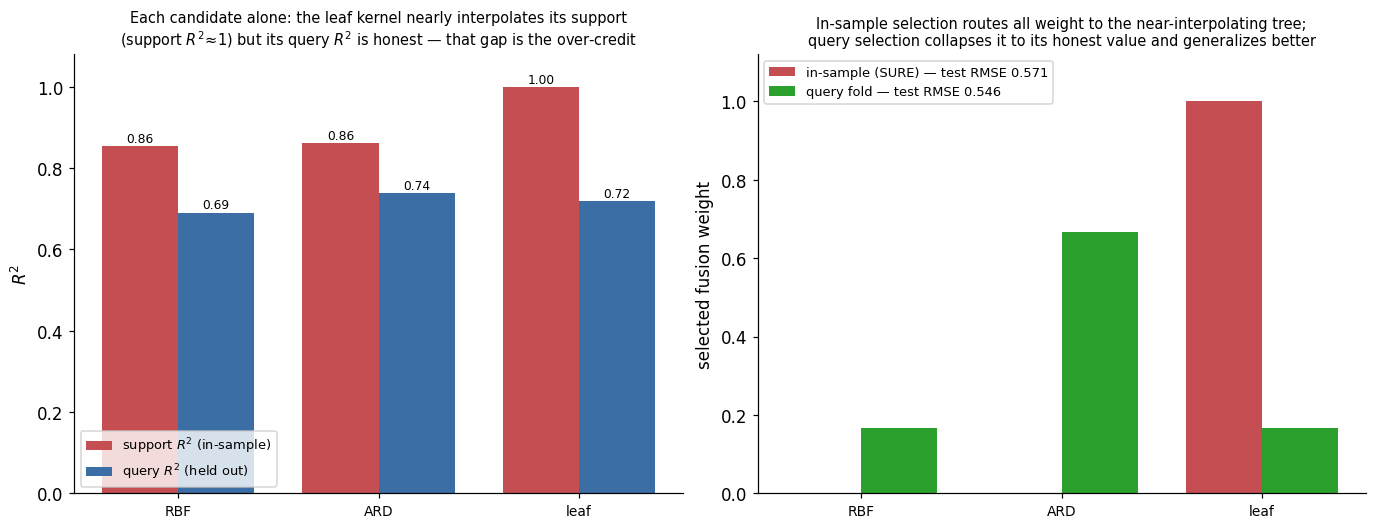

In [6]:
ch07.make_credit_figure(cal)
plt.show()

## 7.3  SURE tracks the true risk — for a *fixed* smoother

On a controlled problem with a **known** clean signal f, the true denoising risk
R(S) = ‖Sx − f‖²/p is computable. Fix an RBF smoother and sweep the ridge: SURE (which
never sees f) tracks R and selects near the oracle, while the in-sample residual slides
to zero, dives **below the noise floor σ²**, and picks interpolation.

In [7]:
sr = ch07.sure_tracks_risk()
print(f"corr(SURE, true risk)        = {sr['corr_sure']:.3f}")
print(f"corr(in-sample, true risk)   = {sr['corr_insample']:.3f}")
print(f"oracle true risk             = {sr['true_min']:.4f}")
print(f"  SURE-selected true risk    = {sr['true_at_sure']:.4f}   (near-oracle)")
print(f"  in-sample-selected risk    = {sr['true_at_insample']:.4f}   (interpolation, ~3× worse)")
assert sr["corr_sure"] > 0.95 and sr["corr_sure"] > sr["corr_insample"]

corr(SURE, true risk)        = 0.991
corr(in-sample, true risk)   = 0.465
oracle true risk             = 0.3465
  SURE-selected true risk    = 0.3498   (near-oracle)
  in-sample-selected risk    = 1.0050   (interpolation, ~3× worse)


## 7.4  The capacity map (Thm D)

The excess risk of a *learned* kernel splits into a fixed kernel-ridge term plus a
**selection** term of size √(𝔠(Θ)/n). That parameter count decomposes: raising the
free-atom count (tree leaf count K) widens the family fastest (Cor. D.2, √K), while
adding convex banks is near-free (Cor. D.3, √log H).

In [8]:
cap = ch07.capacity_map(cal)
free = pd.DataFrame(cap["free"])[["K", "train", "test", "gap"]]
banks = pd.DataFrame(cap["banks"])[["H", "train", "test", "gap"]]
print("FREE ATOMS (leaf count K) — gap grows:")
print(free.round(3).to_string(index=False))
print("\nCONVEX BANKS (count H) — gap flat once a useful scale is in the bank:")
print(banks.round(3).to_string(index=False))

FREE ATOMS (leaf count K) — gap grows:
    K  train  test   gap
  589  0.294 0.592 0.297
 1099  0.182 0.608 0.426
 2073  0.061 0.581 0.520
 6260  0.014 0.569 0.555
15979  0.008 0.567 0.559
33763  0.006 0.584 0.577

CONVEX BANKS (count H) — gap flat once a useful scale is in the bank:
 H  train  test   gap
 1  0.013 0.956 0.942
 2  0.022 0.716 0.694
 4  0.035 0.645 0.610
 8  0.050 0.652 0.602
16  0.060 0.656 0.596
32  0.066 0.659 0.593


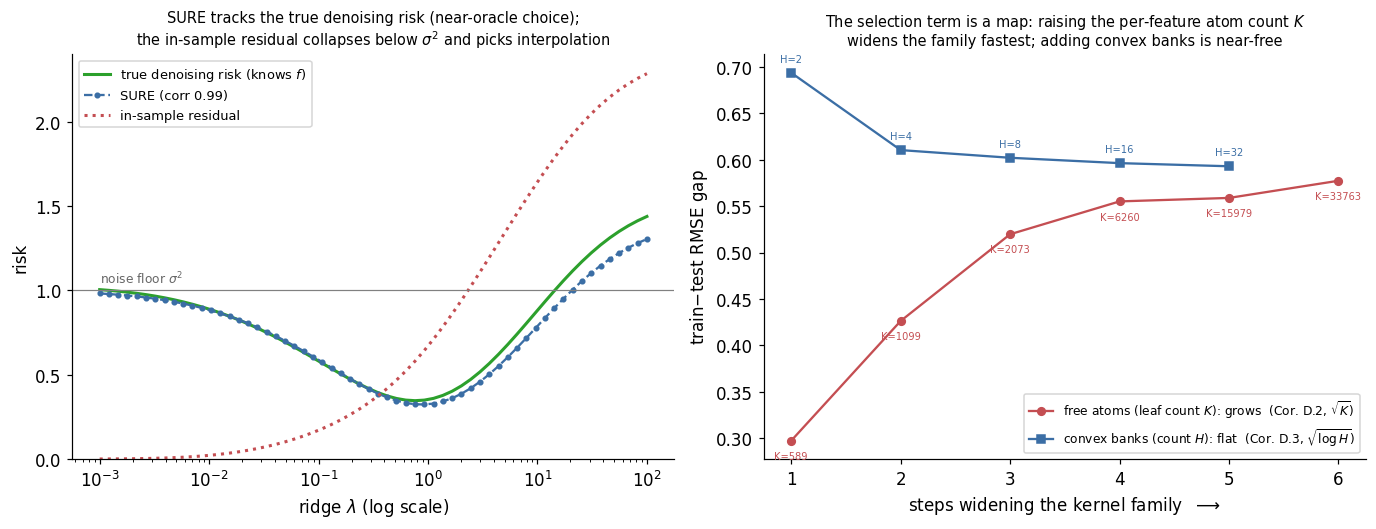

In [9]:
ch07.make_capacity_figure(cal)
plt.show()

## 7.5  Explorer — watch in-sample mislead while SURE tells the truth

Slide the ridge λ on the controlled denoising problem. The in-sample residual always
prefers smaller λ (interpolation); SURE and the true risk agree on the honest λ. The
vertical line is your λ; the markers are the SURE-, in-sample-, and oracle-selected λ.

In [10]:
from ipywidgets import interact, FloatLogSlider

_sr = ch07.sure_tracks_risk()


def explore(log10_lam=0.0):
    lam = 10.0 ** log10_lam
    i = int(np.argmin(np.abs(_sr["lams"] - lam)))
    fig, ax = plt.subplots(figsize=(8.2, 4.6), constrained_layout=True)
    ax.semilogx(_sr["lams"], _sr["true"], "-", color="#2ca02c", lw=2,
                label="true denoising risk (knows f)")
    ax.semilogx(_sr["lams"], _sr["sure"], "--o", color="#3b6ea5", ms=3, label="SURE")
    ax.semilogx(_sr["lams"], _sr["insample"], ":", color="#c44e52", lw=2,
                label="in-sample residual")
    ax.axhline(_sr["sigma2"], color="0.5", lw=0.8)
    ax.text(_sr["lams"][0], _sr["sigma2"] * 1.03, "noise floor σ²", fontsize=8, color="0.4")
    ax.axvline(_sr["lams"][i], color="k", lw=1.0, ls="-", alpha=0.6)
    for lname, color, mk in [("lam_sure", "#3b6ea5", "SURE"),
                             ("lam_insample", "#c44e52", "in-sample"),
                             ("lam_true", "#2ca02c", "oracle")]:
        ax.axvline(_sr[lname], color=color, lw=1.0, ls="--", alpha=0.7)
    ax.set_xlabel("ridge λ (your slider = black line)"); ax.set_ylabel("risk")
    ax.set_ylim(0, max(_sr["insample"].max(), _sr["true"].max()) * 1.05)
    ax.set_title(f"λ = {lam:.3g}   |   true risk here = {_sr['true'][i]:.3f}  "
                 f"(oracle {_sr['true_min']:.3f})", fontsize=10)
    ax.legend(fontsize=9, loc="upper left")
    plt.show()


interact(explore, log10_lam=FloatLogSlider(value=1.0, base=10, min=-3, max=2, step=0.1,
                                           description="log₁₀ λ", readout_format=".2f"));

interactive(children=(FloatLogSlider(value=1.0, description='log₁₀ λ', max=2.0, min=-3.0, readout_format='.2f'…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm the optimism identity: for a fixed smoother, the in-sample residual
equals R(S) + σ² − (2σ²/p)·tr S, so it falls below σ² as tr S → p. Using `sure_tracks_risk`,
verify the in-sample residual at the smallest λ is below σ².

In [11]:
# TODO: from sr = ch07.sure_tracks_risk(), check insample[0] < sigma2
below_floor = None
print(below_floor)

None


<details><summary>Solution</summary>

```python
sr = ch07.sure_tracks_risk()
below_floor = bool(sr["insample"][0] < sr["sigma2"])   # True — interpolation dives below σ²
print(below_floor, sr["insample"][0], sr["sigma2"])
```
As λ → 0 the smoother interpolates, tr S → p, and the optimism term 2σ²·tr S/p → 2σ²,
so the in-sample residual → R + σ² − 2σ² = R − σ² < σ². It looks like the smoother
removed more error than the noise contains — the basis of the over-credit problem.
</details>

**(⋆)** Show the over-credit is specific to the *supervised* kernel. Compute the
support-minus-query R² gap for each channel and confirm the leaf/tree gap is the largest.

In [12]:
# TODO: from ch07.per_channel_credit(cal), find the channel with the largest gap
worst_channel = None
print(worst_channel)

None


<details><summary>Solution</summary>

```python
rows = ch07.per_channel_credit(cal)
worst_channel = max(rows, key=lambda r: r["gap"])["name"]
print(worst_channel)        # 'leaf / tree (Ch. 4)' — the supervised kernel over-credits most
```
The RBF and ARD kernels are fixed (or fit on distances/held-out), so their support fit is
not optimistic. The leaf kernel is fit to the labels it is then scored on, so its support
residual is optimistically small and its support-vs-query gap is the largest.
</details>

---
*Companion to Chapter 7 of **The Learned Kernel**. The over-credit demonstration, the SURE
tracking experiment and the capacity map come from `lkbook.chapters.ch07` — the same code
the book's figures are generated from. Reuses the ARD kernel of Ch. 3 and the leaf kernel
of Ch. 4.*